# Notebook 02: Differential Expression (Reproduction)

Two separate DESeq2 models are fit, one for 24h samples and one for 96h samples, each using the design **~condition.** This is consistent with Conti et al.'s own analysis approach, confirmed from their published analysis code, which used separate result directories per timepoint rather than a combined interaction model. It also correctly avoids conflating real biological time-dependence with the different library preparation protocols used at each timepoint.

Three contrasts are extracted per timepoint: GE_vs_RNP_NEG and GE_ANAK_vs_GE (both confirmed directly from the authors' code), plus GE_ANAK_vs_RNP_NEG (own analysis for extension step). 

In [1]:
import pandas as pd
import os

from hspc_response.io import load_config, resolve_path, load_counts_matrix
from hspc_response.differential_expression import build_dds, run_contrast, flag_nonconverged
from hspc_response.plotting import plot_volcano, plot_ma

### Load filtered data

In [2]:
config = load_config()

# Load filtered counts (from notebook 01) for each timepoint
counts_24h_filtered = pd.read_csv(resolve_path(config["paths"]["counts_24h_filtered"]), index_col=0)
counts_96h_filtered = pd.read_csv(resolve_path(config["paths"]["counts_96h_filtered"]), index_col=0)

# Load metadata for each timepoint
metadata_24h = pd.read_csv(resolve_path(config["paths"]["metadata_24h"]))
metadata_96h = pd.read_csv(resolve_path(config["paths"]["metadata_96h"]))

# Confirm expected shapes: 16,907 genes at 24h, 20,536 genes at 96h, 9 samples each
print(counts_24h_filtered.shape)  # IT SHOULD BE: (16907, 9)
print(counts_96h_filtered.shape)  # IT SHOULD BE: (20536, 9)

(16907, 9)
(20536, 9)


### Fit the 24h model

In [3]:
# Build and fit the DESeq2 model for 24h samples using the design formula and reference level from config
dds_24h = build_dds(
    counts_24h_filtered, metadata_24h,
    group_col="condition", sample_id_col="sample_id",
    design=config["design"]["formula"],
    reference_level=config["design"]["reference_levels"]["condition"],
)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 1.71 seconds.

Fitting dispersion trend curve...
... done in 0.20 seconds.

Fitting MAP dispersions...
... done in 1.98 seconds.

Fitting LFCs...
... done in 1.18 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



### Fit the 96h model

In [4]:
# Build and fit the DESeq2 model for 96h samples using the design formula and reference level from config
dds_96h = build_dds(
    counts_96h_filtered, metadata_96h,
    group_col="condition", sample_id_col="sample_id",
    design=config["design"]["formula"],
    reference_level=config["design"]["reference_levels"]["condition"],
)

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.16 seconds.

Fitting dispersion trend curve...
... done in 0.28 seconds.

Fitting MAP dispersions...
... done in 2.56 seconds.

Fitting LFCs...
... done in 1.56 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



### Convergence diagnostics

In [5]:
# Check convergence for both fitted models: how many genes failed to converge on the LFC fitting step
for label, dds in [("24h", dds_24h), ("96h", dds_96h)]:
    n_total = dds.var.shape[0]
    n_nonconverged = (~dds.var["_LFC_converged"]).sum()
    print(f"{label}: {n_nonconverged}/{n_total} genes non-converged ({n_nonconverged/n_total:.2%})")

24h: 0/16907 genes non-converged (0.00%)
96h: 0/20536 genes non-converged (0.00%)


### Extract contrasts

For each timepoint, extract three contrasts: 
- GE_vs_RNP_NEG 
- GE_ANAK_vs_GE (both confirmed from the authors' own analysis code)
- GE_ANAK_vs_RNP_NEG (additional contrast)

In [6]:
results = {}

# Extract all three contrasts for both timepoints, using the contrast definitions and their numerator/denominator levels from config
for timepoint, dds in [("24h", dds_24h), ("96h", dds_96h)]:
    for contrast_cfg in config["design"]["contrasts"]:
        name = contrast_cfg["name"]
        numerator = contrast_cfg["numerator"]
        denominator = contrast_cfg["denominator"]

        res_df = run_contrast(dds, group_col="condition", numerator=numerator, denominator=denominator)
        res_df = flag_nonconverged(dds, res_df)

        results[(timepoint, name)] = res_df
        print(f"{timepoint} | {name}: {res_df.shape[0]} genes")

Running Wald tests...
... done in 2.27 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition GE vs RNP_NEG
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
WASH7P       63.230671        0.338451  0.296880  1.140024  0.254276  0.624368
MIR6859-1    11.891070       -0.866915  0.611896 -1.416768  0.156551       NaN
AL627309.7   31.105285        0.531821  0.355704  1.495119  0.134883  0.479009
AL627309.5   11.665217       -0.343651  0.560329 -0.613301  0.539677       NaN
WASH9P       85.700540        0.009130  0.228130  0.040020  0.968077  0.990813
...                ...             ...       ...       ...       ...       ...
AC011043.1  129.726910       -0.234095  0.178230 -1.313442  0.189034  0.549937
AL354822.1   14.583241       -0.754802  0.529524 -1.425436  0.154031       NaN
AL592183.1  178.132630       -0.183538  0.188568 -0.973326  0.330391  0.688885
AC240274.1   48.847480        0.279646  0.263309  1.062043  0.288216  0.654633
AC004556.3   28.590760        0.228381  0.357655  0.638552  0.523115 

... done in 0.47 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition GE_ANAK vs GE
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
WASH7P       63.230671       -0.093060  0.287430 -0.323768  0.746114  0.999906
MIR6859-1    11.891070        1.021665  0.595536  1.715539  0.086247  0.999906
AL627309.7   31.105285       -0.139861  0.335777 -0.416528  0.677024  0.999906
AL627309.5   11.665217        0.489942  0.541178  0.905324  0.365294  0.999906
WASH9P       85.700540       -0.064786  0.223548 -0.289808  0.771963  0.999906
...                ...             ...       ...       ...       ...       ...
AC011043.1  129.726910       -0.197708  0.178485 -1.107705  0.267989  0.999906
AL354822.1   14.583241        0.799573  0.516749  1.547314  0.121788  0.999906
AL592183.1  178.132630        0.006982  0.186802  0.037379  0.970183  0.999906
AC240274.1   48.847480       -0.291691  0.255248 -1.142777  0.253131  0.999906
AC004556.3   28.590760        0.196804  0.336980  0.584024  0.559204 

... done in 0.49 seconds.

Running Wald tests...


...

... done in 0.49 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition GE vs RNP_NEG
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.6   24.267230        0.446913  0.694057  0.643914  0.519631  0.999904
AL627309.7   17.001004        0.205738  1.416098  0.145285  0.884486  0.999904
WASH9P       25.352244        0.166080  0.733758  0.226341  0.820936  0.999904
AP006222.1   10.207273       -0.374293  1.514856 -0.247082  0.804845       NaN
U6           18.923031        0.571769  1.046660  0.546280  0.584874  0.999904
...                ...             ...       ...       ...       ...       ...
AL592183.1  101.251869        0.241266  0.399164  0.604429  0.545559  0.999904
AC240274.1   66.226638       -0.017625  0.505777 -0.034848  0.972201  0.999904
AC004556.3    8.770670        0.124511  1.515787  0.082143  0.934533       NaN
AC007325.4   20.884309        1.239303  0.707540  1.751566  0.079849  0.999904
AC007325.2    6.871908        0.121274  1.813931  0.066857  0.946696 

... done in 0.55 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition GE_ANAK vs GE
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.6   24.267230       -0.390938  0.695923 -0.561754  0.574284  0.999916
AL627309.7   17.001004       -0.360540  1.419684 -0.253958  0.799528  0.999916
WASH9P       25.352244       -0.081802  0.734955 -0.111302  0.911377  0.999916
AP006222.1   10.207273        0.539045  1.514996  0.355806  0.721986  0.999916
U6           18.923031        0.510539  1.034619  0.493455  0.621691  0.999916
...                ...             ...       ...       ...       ...       ...
AL592183.1  101.251869        0.043889  0.398473  0.110144  0.912295  0.999916
AC240274.1   66.226638       -0.189075  0.508603 -0.371754  0.710076  0.999916
AC004556.3    8.770670       -0.842313  1.534868 -0.548785  0.583153  0.999916
AC007325.4   20.884309        0.285694  0.678704  0.420941  0.673798  0.999916
AC007325.2    6.871908        1.067976  1.794332  0.595194  0.551714 

... done in 0.50 seconds.



## Significant gene counts per contrast

Counts genes at padj<0.05, matching Conti et al.'s exact significance criterion (no additional fold-change threshold, since none was specified in their methods).

In [7]:
padj_threshold = config["thresholds"]["padj"]

# Count significant genes (padj<0.05) for each timepoint/contrast combination
for (timepoint, name), df in results.items():
    n_sig = (df["padj"] < padj_threshold).sum()
    print(f"{timepoint} | {name}: {n_sig} significant genes (padj<{padj_threshold})")

24h | GE_vs_RNP_NEG: 560 significant genes (padj<0.05)
24h | GE_ANAK_vs_GE: 0 significant genes (padj<0.05)
24h | GE_ANAK_vs_RNP_NEG: 1167 significant genes (padj<0.05)
96h | GE_vs_RNP_NEG: 39 significant genes (padj<0.05)
96h | GE_ANAK_vs_GE: 0 significant genes (padj<0.05)
96h | GE_ANAK_vs_RNP_NEG: 84 significant genes (padj<0.05)


## GE_ANAK_vs_GE

Zero genes reach individual significance in this contrast at either timepoint. This looks at the raw distribution of log2 fold changes, p-values, and padj values to understand whether this reflects genuinely flat signal or borderline results that failed correction.

In [8]:
# Look at the full distribution and the smallest padj values for GE_ANAK_vs_GE at each timepoint
for timepoint in ["24h", "96h"]:
    df = results[(timepoint, "GE_ANAK_vs_GE")]
    print(f"\n{timepoint} GE_ANAK_vs_GE:")
    print(df[["log2FoldChange", "pvalue", "padj"]].describe())
    print("\nSmallest padj values:")
    print(df.sort_values("padj").head(10)[["log2FoldChange", "pvalue", "padj"]])


24h GE_ANAK_vs_GE:
       log2FoldChange        pvalue          padj
count    16907.000000  16905.000000  1.690500e+04
mean         0.005942      0.610623  9.999058e-01
std          0.218855      0.251482  4.441023e-16
min         -2.192726      0.001899  9.999058e-01
25%         -0.079105      0.424648  9.999058e-01
50%         -0.004481      0.637925  9.999058e-01
75%          0.080557      0.824815  9.999058e-01
max          1.758990      0.999906  9.999058e-01

Smallest padj values:
            log2FoldChange    pvalue      padj
WASH7P           -0.093060  0.746114  0.999906
VRK1             -0.045228  0.620662  0.999906
RPL3P4           -0.120748  0.562369  0.999906
AL162151.2       -0.132000  0.787119  0.999906
SETD3            -0.036457  0.739679  0.999906
CCNK              0.015462  0.859973  0.999906
CCDC85C           0.202989  0.280989  0.999906
EVL               0.120028  0.190017  0.999906
DEGS2             0.527381  0.223463  0.999906
YY1              -0.051874  0.562347 

## Sensitivity check: Did the filtering step affect the GE_ANAK_vs_GE result?

Since low-count filtering was an additional QC step that was not part of the original paper, this checks whether skipping it changes the outcome for the comparison that showed no significant genes above. This tests whether the filtering choice, rather than genuine biology, is responsible for the null result.

In [9]:
# Reload UNFILTERED counts for comparison
counts_24h_unfiltered = load_counts_matrix(resolve_path(config["paths"]["counts_24h"]))
counts_96h_unfiltered = load_counts_matrix(resolve_path(config["paths"]["counts_96h"]))

# Fit models on unfiltered data
dds_24h_unfiltered = build_dds(
    counts_24h_unfiltered, metadata_24h,
    group_col="condition", sample_id_col="sample_id",
    design=config["design"]["formula"],
    reference_level=config["design"]["reference_levels"]["condition"],
)

dds_96h_unfiltered = build_dds(
    counts_96h_unfiltered, metadata_96h,
    group_col="condition", sample_id_col="sample_id",
    design=config["design"]["formula"],
    reference_level=config["design"]["reference_levels"]["condition"],
)

# Check if GE_ANAK_vs_GE still shows 0 significant genes without filtering
for label, dds in [("24h_unfiltered", dds_24h_unfiltered), ("96h_unfiltered", dds_96h_unfiltered)]:
    res_df = run_contrast(dds, group_col="condition", numerator="GE_ANAK", denominator="GE")
    n_sig = (res_df["padj"] < padj_threshold).sum()
    print(f"{label} | GE_ANAK_vs_GE: {n_sig} significant genes / {res_df.shape[0]} total genes tested")

Fitting size factors...
... done in 0.01 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 2.96 seconds.

Fitting dispersion trend curve...
... done in 0.40 seconds.

Fitting MAP dispersions...
... done in 3.44 seconds.

Fitting LFCs...
... done in 7.37 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 0 outlier genes.

Fitting size factors...
... done in 0.03 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 7.80 seconds.

Fitting dispersion trend curve...
... done in 0.88 seconds.

Fitting MAP dispersions...
... done in 10.38 seconds.

Fitting LFCs...
... done in 7.38 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 10.41 seconds.



Log2 fold change & Wald test p-value: condition GE_ANAK vs GE
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
DDX11L1       0.119569        0.918632  4.428536  0.207435  0.835670  0.999973
WASH7P       63.102444       -0.091667  0.298258 -0.307340  0.758584  0.999973
MIR6859-1    11.872205        1.027424  0.626248  1.640602  0.100880  0.999973
MIR1302-2HG   0.189670        1.736350  4.332467  0.400776  0.688585  0.999973
MIR1302-2     0.000000             NaN       NaN       NaN       NaN       NaN
...                ...             ...       ...       ...       ...       ...
AL353644.2    0.000000             NaN       NaN       NaN       NaN       NaN
AC007325.3    0.000000             NaN       NaN       NaN       NaN       NaN
AC007325.1    0.117893        0.918632  4.428536  0.207435  0.835670  0.999973
AC007325.4    3.582087       -0.587197  1.024764 -0.573007  0.566640  0.999973
AC007325.2    5.700874        0.462221  0.950009  0.486544  0.626582 

Running Wald tests...
... done in 3.01 seconds.



Log2 fold change & Wald test p-value: condition GE_ANAK vs GE
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
DDX11L1       0.196683       -1.601159  4.330022 -0.369781  0.711546  0.999997
WASH7P        1.931300       -1.860440  2.029145 -0.916859  0.359217  0.999997
MIR6859-1     2.686663        1.169377  1.911341  0.611810  0.540664  0.999997
MIR1302-2HG   0.000000             NaN       NaN       NaN       NaN       NaN
MIR1302-2     0.000000             NaN       NaN       NaN       NaN       NaN
...                ...             ...       ...       ...       ...       ...
AL353644.2    0.000000             NaN       NaN       NaN       NaN       NaN
AC007325.3    0.000000             NaN       NaN       NaN       NaN       NaN
AC007325.1    0.098342       -0.764961  4.427379 -0.172780  0.862825  0.999997
AC007325.4   20.873649        0.284474  0.640222  0.444337  0.656799  0.999997
AC007325.2    6.870555        1.066490  1.697879  0.628131  0.529918 

In [10]:
# Save DE results
tables_dir = resolve_path(config["paths"]["tables_dir"])
os.makedirs(tables_dir, exist_ok=True)

for (timepoint, name), df in results.items():
    out_path = tables_dir / f"{timepoint}_{name}.csv"
    df.to_csv(out_path)
    print(f"Saved: {out_path}")

Saved: /Users/kim/Desktop/Projects-Programming/hspc-rnaseq-gene-editing-response/results/tables/24h_GE_vs_RNP_NEG.csv
Saved: /Users/kim/Desktop/Projects-Programming/hspc-rnaseq-gene-editing-response/results/tables/24h_GE_ANAK_vs_GE.csv
Saved: /Users/kim/Desktop/Projects-Programming/hspc-rnaseq-gene-editing-response/results/tables/24h_GE_ANAK_vs_RNP_NEG.csv
Saved: /Users/kim/Desktop/Projects-Programming/hspc-rnaseq-gene-editing-response/results/tables/96h_GE_vs_RNP_NEG.csv
Saved: /Users/kim/Desktop/Projects-Programming/hspc-rnaseq-gene-editing-response/results/tables/96h_GE_ANAK_vs_GE.csv
Saved: /Users/kim/Desktop/Projects-Programming/hspc-rnaseq-gene-editing-response/results/tables/96h_GE_ANAK_vs_RNP_NEG.csv


## Volcano and MA plots

Visualizes all six contrasts (three per timepoint), using padj<0.05 as the significance threshold, matching Conti et al.'s paper.

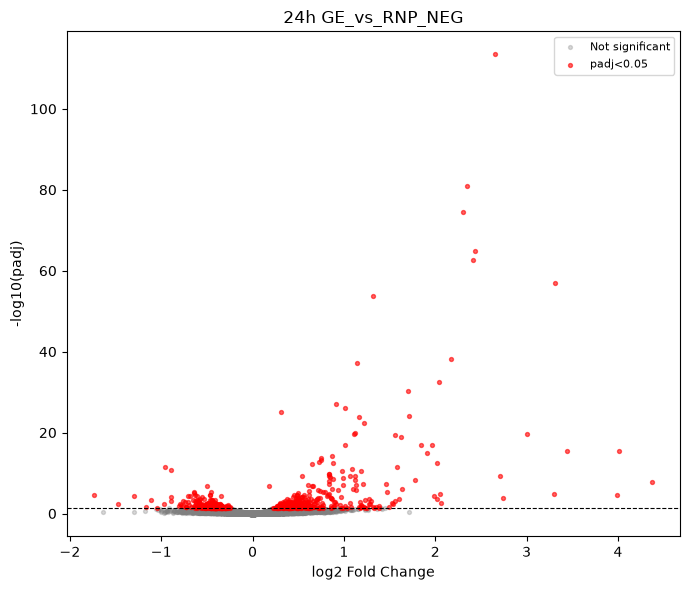

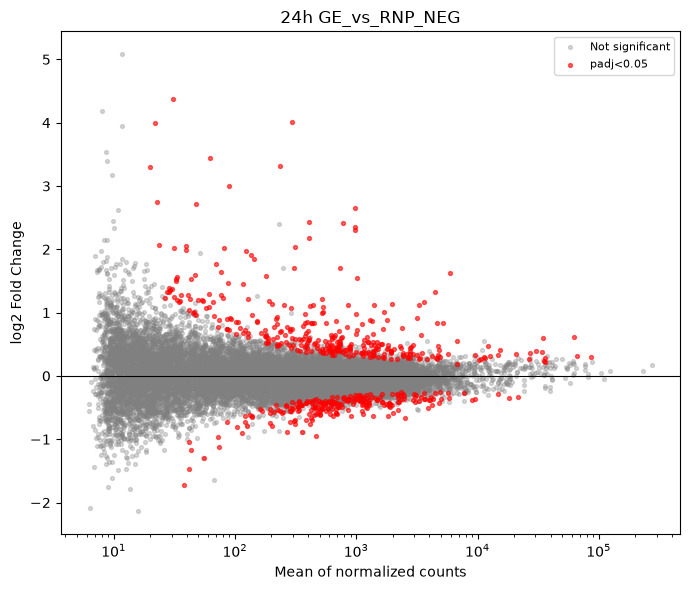

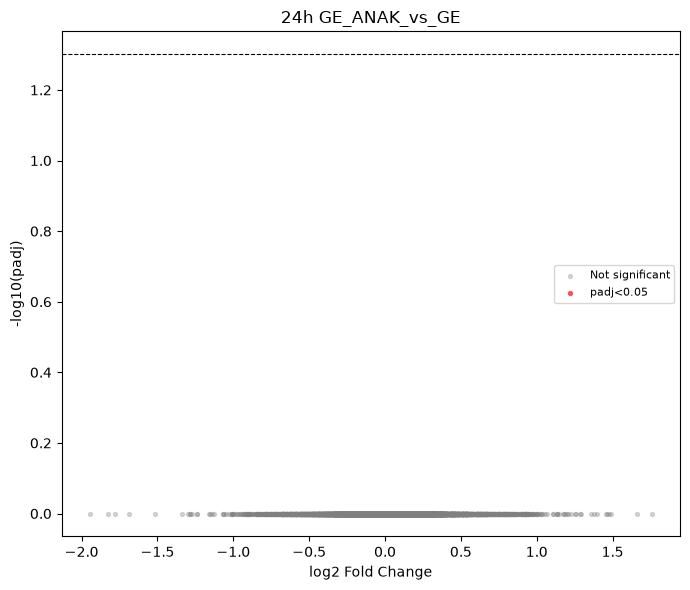

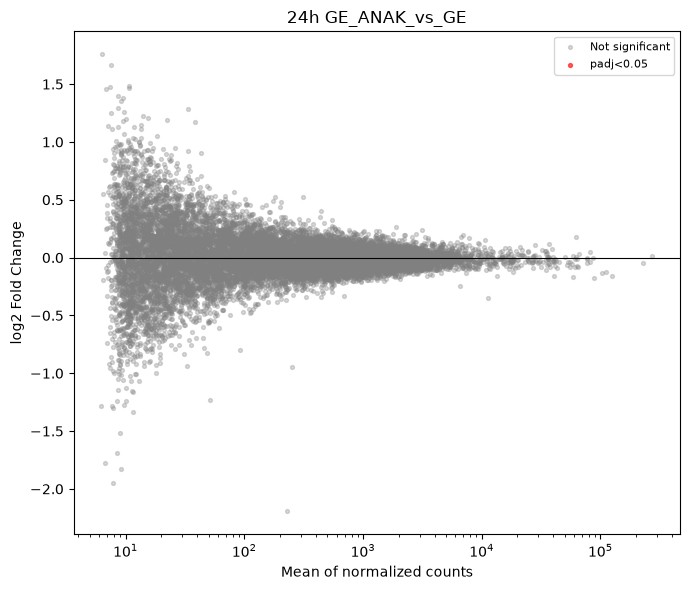

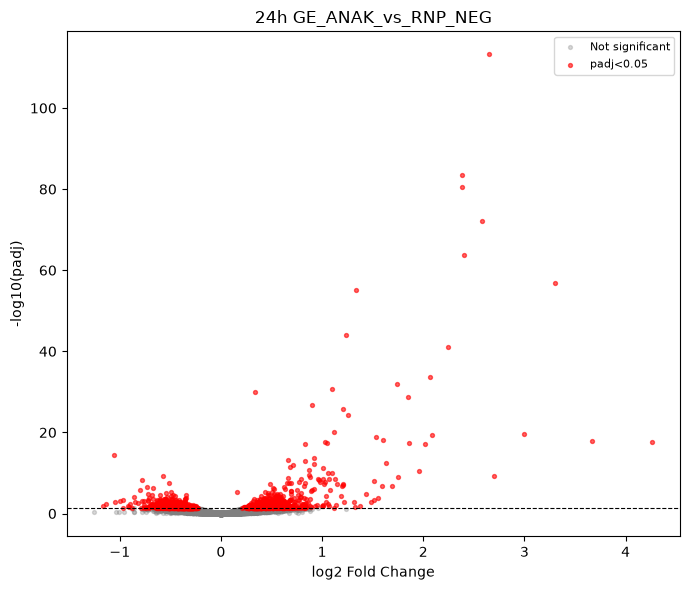

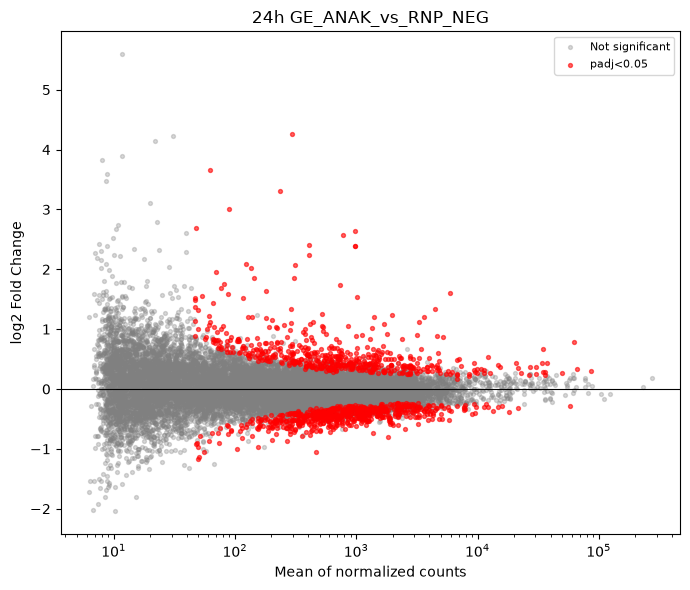

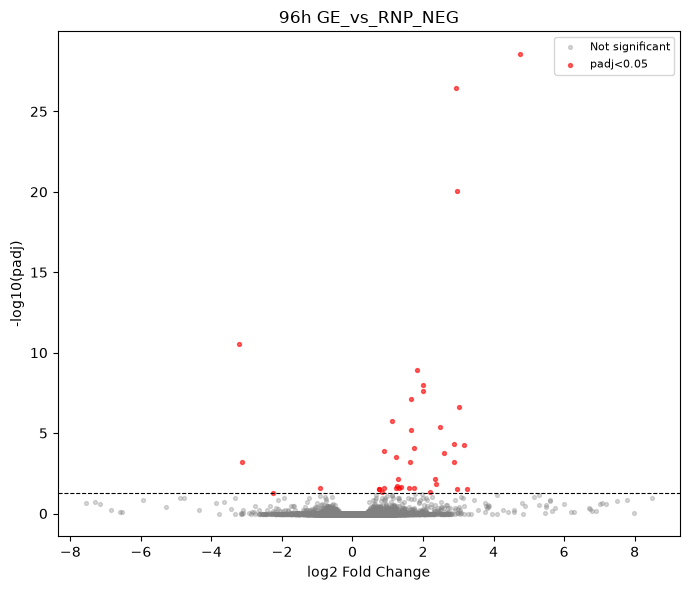

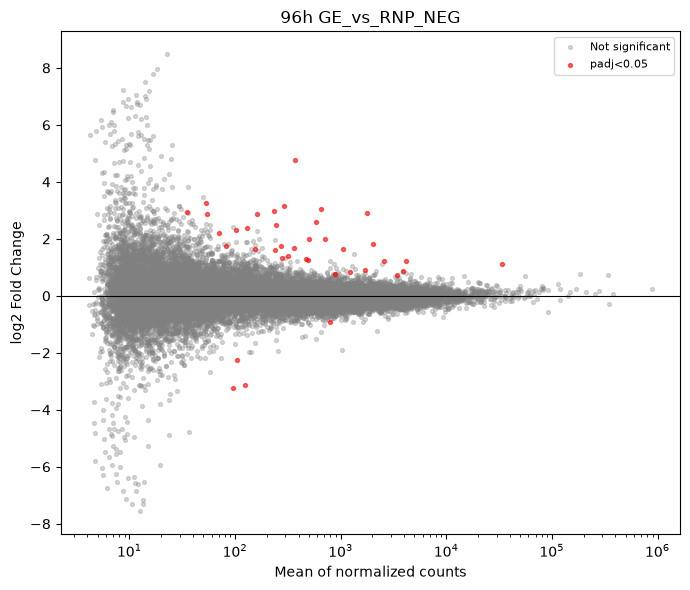

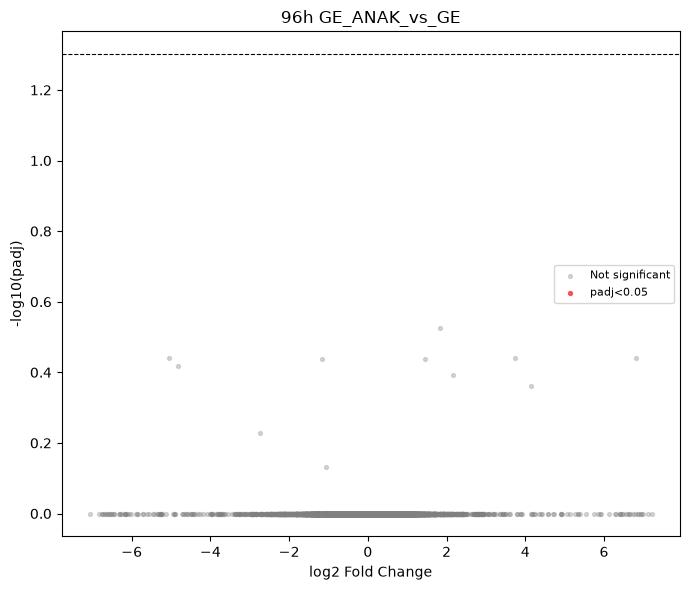

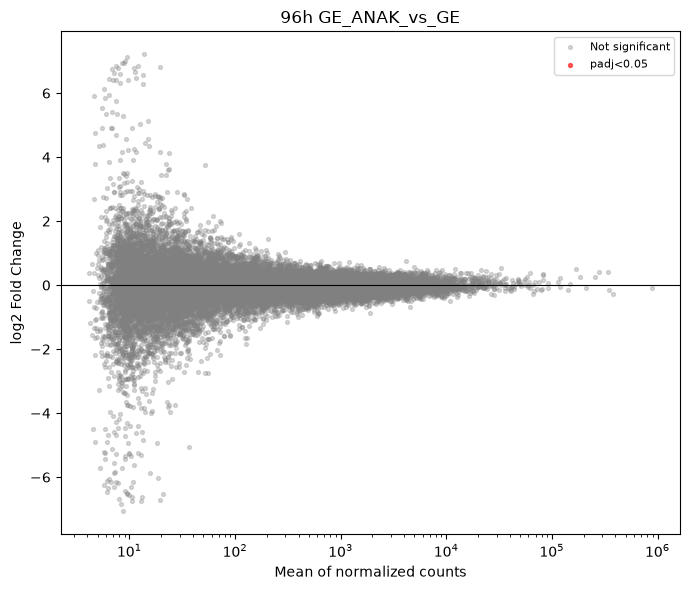

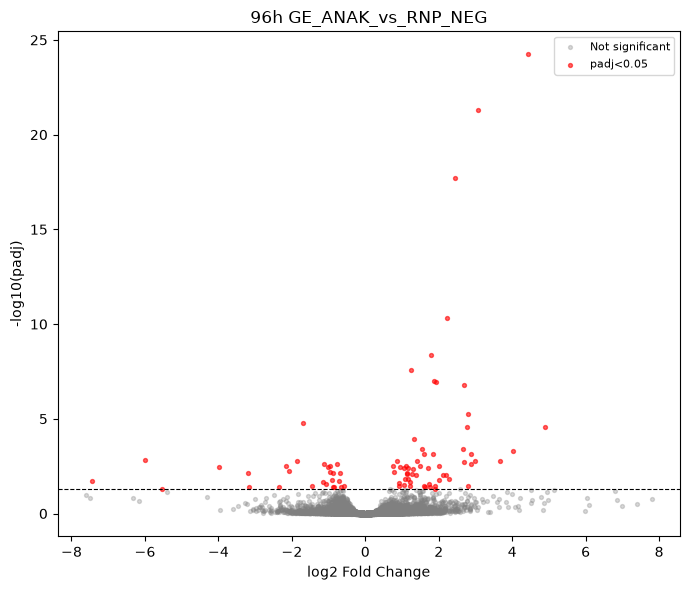

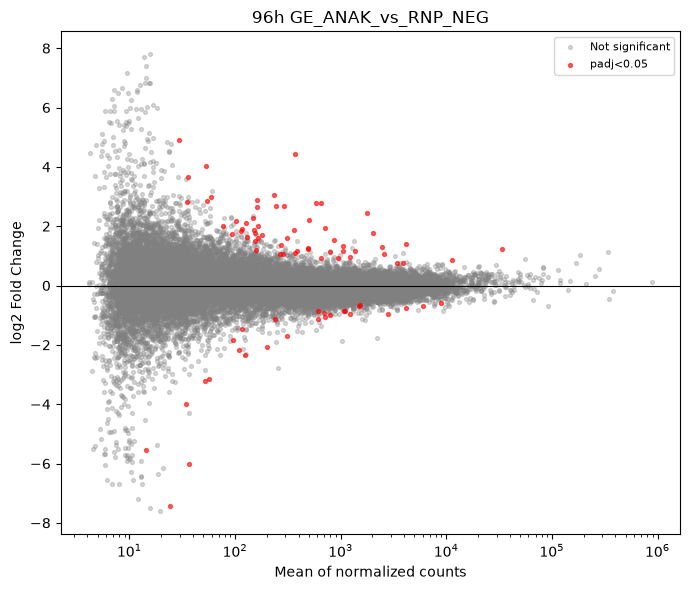

In [11]:
# Plot volcano and MA plots to visualize the contrasts
for (timepoint, name), df in results.items():
    plot_volcano(df, padj_threshold=padj_threshold, title=f"{timepoint} {name}",
                 save_path=resolve_path(f"results/figures/volcano_{timepoint}_{name}.png"))
    plot_ma(df, padj_threshold=padj_threshold, title=f"{timepoint} {name}",
            save_path=resolve_path(f"results/figures/ma_{timepoint}_{name}.png"))